# KNN Ablation Study — TMW `eps_threshold` and `reg`

This notebook performs two ablation studies on a UCR dataset using KNN classification
with precomputed TMW distance matrices:

1. **`eps_threshold` sweep** for two mask types: **`mask_type=1`** and **`mask_type=2`**.
2. **`reg` sweep** at fixed **`eps_threshold=0.2`** for two mask types: **`mask_type=1`** and **`mask_type=2`**.

For each setting, multiple `k` values are evaluated. The regularization ablation also records
runtime components (distance computation time, KNN time, and total time).

In [1]:
import os
import sys
import time
import numpy as np
import pandas as pd
import torch
import gc
from sklearn.metrics import accuracy_score, average_precision_score
from sklearn.preprocessing import LabelEncoder, label_binarize
from aeon.datasets import load_classification
from tqdm.notebook import tqdm
from collections import Counter

# Add parent directory to path for imports
%cd ..
try:
    from distances import TimeSeriesDistance
    print("Successfully imported TimeSeriesDistance from distances.py")
except ImportError as e:
    print(f"Could not import distances.py: {e}")
%cd test_knn_ablation
print(f"Current working directory: {os.getcwd()}")

e:\pyenv\GTCC\KPG-RL\TMW-new
Successfully imported TimeSeriesDistance from distances.py
e:\pyenv\GTCC\KPG-RL\TMW-new\test_knn_ablation
Current working directory: e:\pyenv\GTCC\KPG-RL\TMW-new\test_knn_ablation


In [2]:
try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    pass

In [3]:
# ============================================================================
# CONFIGURATION
# ============================================================================

# --- PATHS ---
DATA_PATH = "../consolidated_datasets/aeon_datasets"
RESULTS_DIR = "ablation_results"

# eps_threshold ablation outputs
EPS_RESULTS_FILE = os.path.join(RESULTS_DIR, "eps_threshold_ablation_results.csv")
EPS_ERROR_LOG_FILE = os.path.join(RESULTS_DIR, "eps_threshold_ablation_errors.txt")

# regularization ablation outputs
REG_RESULTS_FILE = os.path.join(RESULTS_DIR, "regularization_ablation_results.csv")
REG_ERROR_LOG_FILE = os.path.join(RESULTS_DIR, "regularization_ablation_errors.txt")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- DATASET ---
DATASET_NAME = "ToeSegmentation2"

# --- KNN CONFIG ---
KNN_K_VALUES = [1, 3, 5, 7, 9, 11, 13, 15]

# --- DEFAULTS REQUESTED ---
EPS_THRESHOLD_DEFAULT = 0.4
REG_DEFAULT = 0.01

# --- ABLATION 1: eps_threshold sweep ---
EPS_THRESHOLD_VALUES = [0.005, 0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.7, 1.0]
MASK_TYPES_FOR_EPS_ABLATION = [1, 2]

# --- ABLATION 2: regularization (reg) sweep ---
REG_VALUES = [0.0001, 0.001, 0.01, 0.1, 1, 10]
MASK_TYPES_FOR_REG_ABLATION = [1, 2]

# --- FIXED TMW HYPERPARAMETERS (not swept unless explicitly set in loops) ---
TMW_FIXED_PARAMS = {
    "cost_function": "L2",
    "mask_type": 1,
    "reg": REG_DEFAULT,
    "max_iterations": 2000,
    "thres": 1e-5,
    "masked": True,
    "rescale": True,
}

os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Device: {DEVICE}")
print(f"Dataset: {DATASET_NAME}")
print(f"KNN k values: {KNN_K_VALUES}")
print(f"Default eps_threshold: {EPS_THRESHOLD_DEFAULT}")
print(f"Default reg: {REG_DEFAULT}")
print(f"eps_threshold values to sweep: {EPS_THRESHOLD_VALUES}")
print(f"mask types for eps ablation: {MASK_TYPES_FOR_EPS_ABLATION}")
print(f"reg values to sweep: {REG_VALUES}")
print(f"mask types for reg ablation: {MASK_TYPES_FOR_REG_ABLATION}")
print(f"Fixed TMW params baseline: {TMW_FIXED_PARAMS}")

Device: cuda
Dataset: ToeSegmentation2
KNN k values: [1, 3, 5, 7, 9, 11, 13, 15]
Default eps_threshold: 0.4
Default reg: 0.01
eps_threshold values to sweep: [0.005, 0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.7, 1.0]
mask types for eps ablation: [1, 2]
reg values to sweep: [0.0001, 0.001, 0.01, 0.1, 1, 10]
mask types for reg ablation: [1, 2]
Fixed TMW params baseline: {'cost_function': 'L2', 'mask_type': 1, 'reg': 0.01, 'max_iterations': 2000, 'thres': 1e-05, 'masked': True, 'rescale': True}


In [4]:
# ============================================================================
# LOAD AND PREPARE THE SMOOTHSUBSPACE DATASET
# ============================================================================

X_train, y_train_raw = load_classification(DATASET_NAME, split="train", extract_path=DATA_PATH)
X_test, y_test_raw = load_classification(DATASET_NAME, split="test", extract_path=DATA_PATH)

# Handle 3D vs 2D
if X_train.ndim == 3:
    X_train = X_train.squeeze(1)
    X_test = X_test.squeeze(1)

# Handle NaNs
X_train = np.nan_to_num(X_train)
X_test = np.nan_to_num(X_test)

# Label encoding
le = LabelEncoder()
all_labels = np.concatenate([y_train_raw, y_test_raw])
le.fit(all_labels)
y_train = le.transform(y_train_raw)
y_test = le.transform(y_test_raw)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}, classes: {np.unique(y_train)}")
print(f"y_test shape:  {y_test.shape},  classes: {np.unique(y_test)}")
print(f"Series length: {X_train.shape[1]}")

X_train shape: (36, 343)
X_test shape:  (130, 343)
y_train shape: (36,), classes: [0 1]
y_test shape:  (130,),  classes: [0 1]
Series length: 343


In [5]:
# ============================================================================
# CHECKPOINT MANAGER (eps_threshold ablation)
# ============================================================================

def get_processed_entries():
    """Returns a set of (mask_type, eps_threshold, k) tuples already processed."""
    if not os.path.exists(EPS_RESULTS_FILE):
        with open(EPS_RESULTS_FILE, 'w') as f:
            f.write("dataset,mask_type,eps_threshold,k,accuracy,mAP,length,n_train,n_test,n_distances,time_sec\n")
        return set()

    try:
        df = pd.read_csv(EPS_RESULTS_FILE)
        if 'mask_type' not in df.columns:
            # Backward compatibility with old files that only had one mask type.
            df['mask_type'] = 1
        return set(zip(df['mask_type'], df['eps_threshold'], df['k']))
    except Exception:
        return set()


def save_result(mask_type, eps_val, k, acc, map_score, length, n_train, n_test, duration):
    """Save a single eps_threshold ablation result to CSV."""
    n_dists = n_train * n_test
    with open(EPS_RESULTS_FILE, 'a') as f:
        f.write(
            f"{DATASET_NAME},{mask_type},{eps_val},{k},{acc:.5f},{map_score:.5f},"
            f"{length},{n_train},{n_test},{n_dists},{duration:.2f}\n"
        )


def log_failure(mask_type, eps_val, error_msg):
    """Log an eps_threshold ablation failure."""
    with open(EPS_ERROR_LOG_FILE, 'a') as f:
        f.write(
            f"[{time.strftime('%Y-%m-%d %H:%M:%S')}] mask_type={mask_type}, "
            f"eps_threshold={eps_val}: {error_msg}\n"
        )

In [6]:
# ============================================================================
# BATCHING & DISTANCE MATRIX UTILITIES
# ============================================================================

def get_optimal_batch_size(series_length, vram_fraction=0.8):
    """Estimate optimal batch size based on available VRAM and series length."""
    if str(DEVICE) == 'cpu':
        return 512
    try:
        free_mem, _ = torch.cuda.mem_get_info()
        usable_mem = free_mem * vram_fraction
        est_mem = (series_length ** 2 * 4) * 4 + (series_length * 8)
        batch_size = int(usable_mem / est_mem)
        return max(1, min(batch_size, 4096))
    except:
        return 64


def compute_distance_matrix(X_train, X_test, distance_func):
    """
    Precompute full distance matrix between test and train samples.
    Returns numpy array of shape (n_test, n_train).
    """
    n_train = X_train.shape[0]
    n_test = X_test.shape[0]
    length = X_train.shape[1]

    # Add feature dimension if needed (shape: n, seq_len, 1)
    if X_train.ndim == 2:
        X_train = X_train[:, :, np.newaxis]
        X_test = X_test[:, :, np.newaxis]

    X_train_t = torch.tensor(X_train, dtype=torch.float32).to(DEVICE)
    X_test_t = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)

    batch_size = get_optimal_batch_size(length)
    dist_matrix = np.zeros((n_test, n_train), dtype=np.float32)

    for i in range(n_test):
        test_seq = X_test_t[i].unsqueeze(0)
        for j in range(0, n_train, batch_size):
            end_j = min(j + batch_size, n_train)
            current_bs = end_j - j
            batch_train = X_train_t[j:end_j]
            batch_test = test_seq.repeat(current_bs, 1, 1)
            dists = distance_func(batch_test, batch_train)
            dist_matrix[i, j:end_j] = dists.cpu().numpy()
        if (i + 1) % 50 == 0:
            print(f"    Computing distances: {i + 1}/{n_test}...", end='\r')

    return dist_matrix


def run_knn_from_distance_matrix(dist_matrix, y_train, y_test, k_values):
    """
    Run k-NN classification for multiple k values using precomputed distance matrix.
    Returns dict: {k: {'accuracy': acc, 'mAP': map_score}}.
    """
    n_test = dist_matrix.shape[0]
    n_train = dist_matrix.shape[1]
    max_k = max(k_values)

    # Handle case where max_k > n_train  
    effective_max_k = min(max_k, n_train)
    
    top_k_indices = np.argpartition(dist_matrix, effective_max_k - 1, axis=1)[:, :effective_max_k]
    row_indices = np.arange(n_test)[:, np.newaxis]
    top_k_dists = dist_matrix[row_indices, top_k_indices]
    sorted_order = np.argsort(top_k_dists, axis=1)
    top_k_indices_sorted = np.take_along_axis(top_k_indices, sorted_order, axis=1)

    # Determine all unique classes
    all_classes = np.unique(np.concatenate([y_train, y_test]))
    n_classes = len(all_classes)
    
    # Binarize true labels for mAP calculation (One-vs-Rest)
    y_test_bin = label_binarize(y_test, classes=all_classes)
    if n_classes == 2:
        y_test_bin = np.hstack([1 - y_test_bin, y_test_bin])

    results = {}
    for k in k_values:
        if k > n_train:
            print(f"    Warning: k={k} > n_train={n_train}, skipping.")
            continue
        
        predictions = []
        y_score = np.zeros((n_test, n_classes), dtype=np.float64)
        
        for i in range(n_test):
            k_nearest_indices = top_k_indices_sorted[i, :k]
            k_nearest_labels = y_train[k_nearest_indices]
            
            label_counts = Counter(k_nearest_labels)
            most_common = label_counts.most_common(1)[0][0]
            predictions.append(most_common)
            
            # KNN probabilities
            for cls_idx, cls in enumerate(all_classes):
                y_score[i, cls_idx] = label_counts.get(cls, 0) / k
        
        acc = accuracy_score(y_test, predictions)
        
        # Compute mAP
        try:
            ap_per_class = []
            for cls_idx in range(n_classes):
                if y_test_bin[:, cls_idx].sum() > 0:
                    ap = average_precision_score(y_test_bin[:, cls_idx], y_score[:, cls_idx])
                    ap_per_class.append(ap)
            map_score = np.mean(ap_per_class) if ap_per_class else 0.0
        except Exception:
            map_score = 0.0
        
        results[k] = {'accuracy': acc, 'mAP': map_score}

    return results

In [7]:
# ============================================================================
# RUN ABLATION OVER eps_threshold VALUES (for mask_type 1 and 2)
# ============================================================================

def run_ablation():
    """Sweep eps_threshold values for each mask_type, then run KNN."""
    processed = get_processed_entries()
    length = X_train.shape[1]
    n_train = X_train.shape[0]
    n_test = X_test.shape[0]

    print(f"Dataset: {DATASET_NAME}  |  L={length}, Train={n_train}, Test={n_test}")
    print(f"Mask types: {MASK_TYPES_FOR_EPS_ABLATION}")
    print(f"Sweeping eps_threshold over {len(EPS_THRESHOLD_VALUES)} values")
    print("=" * 80)

    all_results = []

    for mask_type in MASK_TYPES_FOR_EPS_ABLATION:
        print(f"\n--- mask_type={mask_type} ---")

        for idx, eps_val in enumerate(EPS_THRESHOLD_VALUES):
            # Check which k values still need processing
            k_values_to_run = [
                k for k in KNN_K_VALUES if (mask_type, eps_val, k) not in processed
            ]

            if not k_values_to_run:
                print(
                    f"[{idx + 1}/{len(EPS_THRESHOLD_VALUES)}] eps_threshold={eps_val} "
                    f"-> all k already done, skipping."
                )
                continue

            print(f"\n[{idx + 1}/{len(EPS_THRESHOLD_VALUES)}] eps_threshold={eps_val}")
            print(f"    k values to run: {k_values_to_run}")

            # Build TMW params for this mask_type and eps_threshold
            tmw_params = {
                **TMW_FIXED_PARAMS,
                "mask_type": int(mask_type),
                "eps_threshold": float(eps_val),
            }

            try:
                dist_func = TimeSeriesDistance("tmw", tmw_params, device=DEVICE)

                start_ts = time.time()
                dist_matrix = compute_distance_matrix(X_train, X_test, dist_func)
                dist_time = time.time() - start_ts

                knn_start = time.time()
                k_results = run_knn_from_distance_matrix(dist_matrix, y_train, y_test, k_values_to_run)
                knn_time = time.time() - knn_start

                total_time = time.time() - start_ts
                best_k = max(k_results, key=lambda k: k_results[k]['accuracy'])
                best_acc = k_results[best_k]['accuracy']
                best_map = k_results[best_k]['mAP']

                print("    Results:")
                for k, metrics in sorted(k_results.items()):
                    marker = " *BEST*" if k == best_k else ""
                    print(f"      k={k}: Acc={metrics['accuracy']:.4f}, mAP={metrics['mAP']:.4f}{marker}")
                    save_result(
                        mask_type=mask_type,
                        eps_val=eps_val,
                        k=k,
                        acc=metrics['accuracy'],
                        map_score=metrics['mAP'],
                        length=length,
                        n_train=n_train,
                        n_test=n_test,
                        duration=dist_time + knn_time / len(k_values_to_run),
                    )
                    all_results.append({
                        "mask_type": mask_type,
                        "eps_threshold": eps_val,
                        "k": k,
                        "accuracy": metrics['accuracy'],
                        "mAP": metrics['mAP'],
                        "time_sec": total_time,
                    })

                print(
                    f"    Best: k={best_k} -> Acc={best_acc:.4f}, mAP={best_map:.4f} "
                    f"| Time: {total_time:.2f}s"
                )

            except Exception as e:
                print(f"    FAILED: {e}")
                log_failure(mask_type, eps_val, str(e))

            torch.cuda.empty_cache()
            gc.collect()

    print("\n" + "=" * 80)
    print("Ablation sweep complete!")
    return all_results


ablation_results = run_ablation()

Dataset: ToeSegmentation2  |  L=343, Train=36, Test=130
Mask types: [1, 2]
Sweeping eps_threshold over 11 values

--- mask_type=1 ---
[1/11] eps_threshold=0.005 -> all k already done, skipping.
[2/11] eps_threshold=0.01 -> all k already done, skipping.
[3/11] eps_threshold=0.05 -> all k already done, skipping.
[4/11] eps_threshold=0.1 -> all k already done, skipping.
[5/11] eps_threshold=0.15 -> all k already done, skipping.
[6/11] eps_threshold=0.2 -> all k already done, skipping.
[7/11] eps_threshold=0.3 -> all k already done, skipping.
[8/11] eps_threshold=0.4 -> all k already done, skipping.
[9/11] eps_threshold=0.5 -> all k already done, skipping.
[10/11] eps_threshold=0.7 -> all k already done, skipping.
[11/11] eps_threshold=1.0 -> all k already done, skipping.

--- mask_type=2 ---
[1/11] eps_threshold=0.005 -> all k already done, skipping.
[2/11] eps_threshold=0.01 -> all k already done, skipping.
[3/11] eps_threshold=0.05 -> all k already done, skipping.
[4/11] eps_threshold=0

In [8]:
# ============================================================================
# COLLECT AND DISPLAY EPS-THRESHOLD ABLATION RESULTS
# ============================================================================

def display_results():
    """Load and display eps_threshold results for each mask type."""
    if not os.path.exists(EPS_RESULTS_FILE):
        print("No eps_threshold results file found.")
        return None

    df = pd.read_csv(EPS_RESULTS_FILE)
    df_valid = df[df['accuracy'] >= 0].copy()

    # Backward compatibility
    if 'mAP' not in df_valid.columns:
        df_valid['mAP'] = 0.0
    if 'mask_type' not in df_valid.columns:
        df_valid['mask_type'] = 1

    print("\n" + "=" * 80)
    print(f"ABLATION RESULTS — eps_threshold on {DATASET_NAME}")
    print("=" * 80)

    for mask_type in sorted(df_valid['mask_type'].unique()):
        df_mask = df_valid[df_valid['mask_type'] == mask_type].copy()

        print(f"\n### mask_type={int(mask_type)} ###")

        print("\n--- Full Accuracy Results ---")
        pivot_acc = df_mask.pivot_table(index='eps_threshold', columns='k', values='accuracy')
        print(pivot_acc.to_string())

        print("\n--- Full mAP Results ---")
        pivot_map = df_mask.pivot_table(index='eps_threshold', columns='k', values='mAP')
        print(pivot_map.to_string())

        print("\n--- Best k per eps_threshold ---")
        idx_best_k = df_mask.groupby('eps_threshold')['accuracy'].idxmax()
        df_best = df_mask.loc[idx_best_k][['mask_type', 'eps_threshold', 'k', 'accuracy', 'mAP', 'time_sec']]
        print(df_best.sort_values('eps_threshold').to_string(index=False))

    best_row = df_valid.loc[df_valid['accuracy'].idxmax()]
    print(
        f"\n*** Overall Best: mask_type={int(best_row['mask_type'])}, "
        f"eps_threshold={best_row['eps_threshold']}, k={int(best_row['k'])}, "
        f"accuracy={best_row['accuracy']:.4f}, mAP={best_row.get('mAP', 0):.4f} ***"
    )

    return df_valid


results_df = display_results()


ABLATION RESULTS — eps_threshold on ToeSegmentation2

### mask_type=1 ###

--- Full Accuracy Results ---
k                   1        3        5        7        9        11       13       15
eps_threshold                                                                        
0.005          0.81538  0.82308  0.86923  0.78462  0.70000  0.66154  0.62308  0.54615
0.010          0.81538  0.83077  0.86923  0.78462  0.71538  0.66923  0.64615  0.54615
0.050          0.88462  0.87692  0.87692  0.89231  0.85385  0.81538  0.80769  0.73846
0.100          0.86923  0.88462  0.87692  0.86923  0.85385  0.84615  0.83846  0.85385
0.150          0.86923  0.88462  0.92308  0.89231  0.87692  0.86923  0.86923  0.83846
0.200          0.90000  0.91538  0.89231  0.90769  0.91538  0.90769  0.90769  0.86154
0.300          0.86923  0.89231  0.91538  0.93846  0.93846  0.93077  0.92308  0.91538
0.400          0.82308  0.83846  0.86923  0.88462  0.88462  0.90000  0.90000  0.90000
0.500          0.76154  0.82308  0

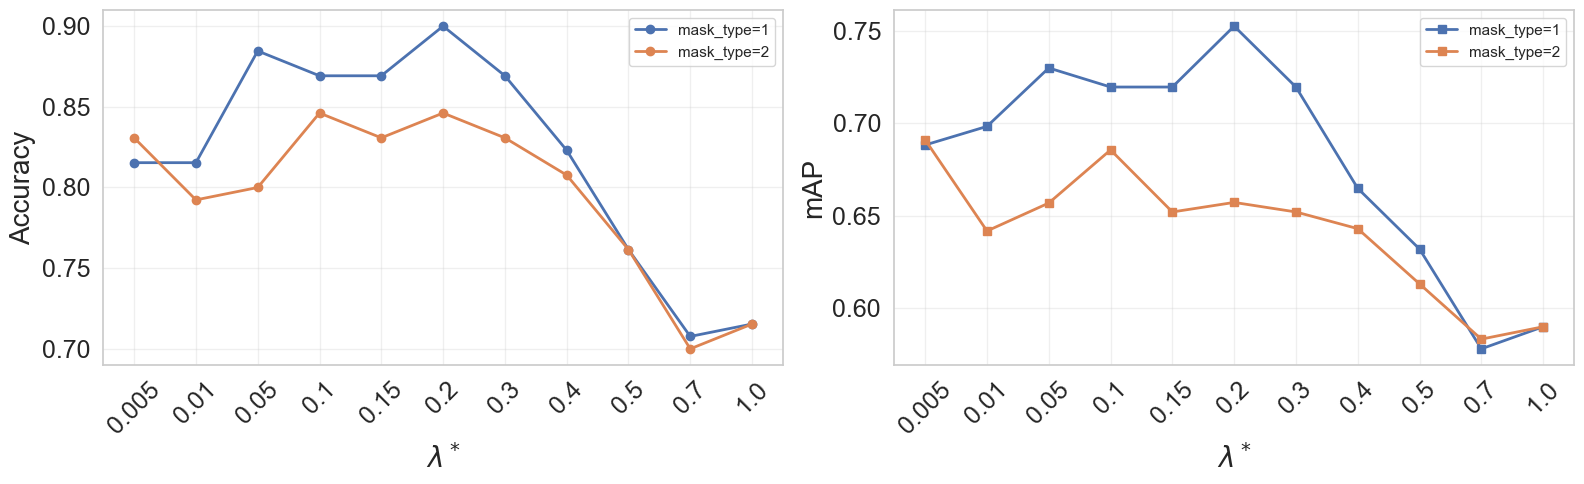

Figure saved to ablation_results\ablation_eps_threshold_mask12_ToeSegmentation2_k1.png


In [9]:
# ============================================================================
# VISUALIZE EPS-THRESHOLD ABLATION RESULTS (k=1 ONLY)
# ============================================================================

import matplotlib.pyplot as plt


def visualize_ablation():
    """Visualize eps_threshold ablation results for both mask types (k=1 only)."""
    if not os.path.exists(EPS_RESULTS_FILE):
        print("No eps_threshold results file found.")
        return

    df = pd.read_csv(EPS_RESULTS_FILE)
    df_valid = df[df['accuracy'] >= 0].copy()

    # Backward compatibility
    if 'mAP' not in df_valid.columns:
        df_valid['mAP'] = 0.0
    if 'mask_type' not in df_valid.columns:
        df_valid['mask_type'] = 1

    # Filter for k=1 only
    df_valid = df_valid[df_valid['k'] == 1].copy()

    if len(df_valid) == 0:
        print("No valid results to visualize for k=1.")
        return

    # Use discrete eps_threshold categories on x-axis
    eps_levels = sorted(df_valid['eps_threshold'].unique())
    eps_levels_str = [str(v) for v in eps_levels]
    label_fontsize = 20
    tick_labelsize = 18
    x_label = r"$\lambda^*$"

    # Keep only two charts: Accuracy and mAP
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # --- Plot 1: Accuracy vs eps_threshold (k=1) ---
    ax1 = axes[0]
    for mask_type in sorted(df_valid['mask_type'].unique()):
        subset = df_valid[df_valid['mask_type'] == mask_type].sort_values('eps_threshold')
        if len(subset) > 0:
            x_cat = subset['eps_threshold'].astype(str)
            ax1.plot(
                x_cat,
                subset['accuracy'],
                marker='o',
                linewidth=2,
                label=f'mask_type={int(mask_type)}',
            )

    ax1.set_xlabel(x_label, fontsize=label_fontsize)
    ax1.set_ylabel('Accuracy', fontsize=label_fontsize)
    # ax1.set_title(f'Accuracy vs eps_threshold on {DATASET_NAME} (k=1)')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    ax1.set_xticks(eps_levels_str)
    ax1.tick_params(axis='x', rotation=45, labelsize=tick_labelsize)
    ax1.tick_params(axis='y', labelsize=tick_labelsize)

    # --- Plot 2: mAP vs eps_threshold (k=1) ---
    ax2 = axes[1]
    for mask_type in sorted(df_valid['mask_type'].unique()):
        subset = df_valid[df_valid['mask_type'] == mask_type].sort_values('eps_threshold')
        if len(subset) > 0:
            x_cat = subset['eps_threshold'].astype(str)
            ax2.plot(
                x_cat,
                subset['mAP'],
                marker='s',
                linewidth=2,
                label=f'mask_type={int(mask_type)}',
            )

    ax2.set_xlabel(x_label, fontsize=label_fontsize)
    ax2.set_ylabel('mAP', fontsize=label_fontsize)
    # ax2.set_title(f'mAP vs eps_threshold on {DATASET_NAME} (k=1)')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    ax2.set_xticks(eps_levels_str)
    ax2.tick_params(axis='x', rotation=45, labelsize=tick_labelsize)
    ax2.tick_params(axis='y', labelsize=tick_labelsize)

    plt.tight_layout()
    fig_path = os.path.join(RESULTS_DIR, f"ablation_eps_threshold_mask12_{DATASET_NAME}_k1.png")
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Figure saved to {fig_path}")


visualize_ablation()


# Regularization Ablation (`reg`) for `mask_type` 1 and 2

This section sweeps `reg` values while fixing `eps_threshold=0.2`.

- Mask types evaluated: `1`, `2`
- Runtime metrics recorded per setting:
  - distance matrix compute time (`dist_time_sec`)
  - KNN evaluation time (`knn_time_sec`)
  - total elapsed time (`total_time_sec`)

In [10]:
# ============================================================================
# RUN REGULARIZATION ABLATION (reg sweep, mask_type in {1, 2})
# ============================================================================

def get_processed_reg_entries():
    """Returns a set of (mask_type, reg, k) tuples already processed."""
    if not os.path.exists(REG_RESULTS_FILE):
        with open(REG_RESULTS_FILE, 'w') as f:
            f.write(
                "dataset,mask_type,eps_threshold,reg,k,accuracy,mAP,length,n_train,n_test,n_distances,dist_time_sec,knn_time_sec,total_time_sec,time_sec_per_k\n"
            )
        return set()

    try:
        df = pd.read_csv(REG_RESULTS_FILE)
        return set(zip(df['mask_type'], df['reg'], df['k']))
    except Exception:
        return set()


def save_reg_result(mask_type, eps_val, reg_val, k, acc, map_score, length, n_train, n_test,
                    dist_time, knn_time, total_time, time_per_k):
    """Save one regularization-ablation result row to CSV."""
    n_dists = n_train * n_test
    with open(REG_RESULTS_FILE, 'a') as f:
        f.write(
            f"{DATASET_NAME},{mask_type},{eps_val},{reg_val},{k},{acc:.5f},{map_score:.5f},"
            f"{length},{n_train},{n_test},{n_dists},{dist_time:.6f},{knn_time:.6f},{total_time:.6f},{time_per_k:.6f}\n"
        )


def log_reg_failure(mask_type, reg_val, error_msg):
    """Log a regularization-ablation failure."""
    with open(REG_ERROR_LOG_FILE, 'a') as f:
        f.write(
            f"[{time.strftime('%Y-%m-%d %H:%M:%S')}] mask_type={mask_type}, reg={reg_val}: {error_msg}\n"
        )


def run_regularization_ablation():
    """Sweep reg for each mask type with eps_threshold fixed to EPS_THRESHOLD_DEFAULT."""
    processed = get_processed_reg_entries()

    length = X_train.shape[1]
    n_train = X_train.shape[0]
    n_test = X_test.shape[0]

    print(f"Dataset: {DATASET_NAME}  |  L={length}, Train={n_train}, Test={n_test}")
    print(f"Regularization ablation with fixed eps_threshold={EPS_THRESHOLD_DEFAULT}")
    print(f"Mask types: {MASK_TYPES_FOR_REG_ABLATION}")
    print(f"reg values: {REG_VALUES}")
    print("=" * 80)

    all_results = []

    for mask_type in MASK_TYPES_FOR_REG_ABLATION:
        print(f"\n--- mask_type={mask_type} ---")

        for idx, reg_val in enumerate(REG_VALUES):
            k_values_to_run = [
                k for k in KNN_K_VALUES if (mask_type, reg_val, k) not in processed
            ]

            if not k_values_to_run:
                print(
                    f"[{idx + 1}/{len(REG_VALUES)}] reg={reg_val} -> all k already processed, skipping."
                )
                continue

            print(f"[{idx + 1}/{len(REG_VALUES)}] reg={reg_val}")
            print(f"    k values to run: {k_values_to_run}")

            tmw_params = {
                **TMW_FIXED_PARAMS,
                "mask_type": int(mask_type),
                "eps_threshold": float(EPS_THRESHOLD_DEFAULT),
                "reg": float(reg_val),
            }

            try:
                dist_func = TimeSeriesDistance("tmw", tmw_params, device=DEVICE)

                start_ts = time.time()
                dist_matrix = compute_distance_matrix(X_train, X_test, dist_func)
                dist_time = time.time() - start_ts

                knn_start = time.time()
                k_results = run_knn_from_distance_matrix(
                    dist_matrix, y_train, y_test, k_values_to_run
                )
                knn_time = time.time() - knn_start

                total_time = time.time() - start_ts
                time_per_k = total_time / max(1, len(k_values_to_run))

                best_k = max(k_results, key=lambda k: k_results[k]['accuracy'])
                best_acc = k_results[best_k]['accuracy']
                best_map = k_results[best_k]['mAP']

                print(f"    dist_time={dist_time:.3f}s, knn_time={knn_time:.3f}s, total={total_time:.3f}s")
                for k, metrics in sorted(k_results.items()):
                    marker = " *BEST*" if k == best_k else ""
                    print(
                        f"      k={k}: Acc={metrics['accuracy']:.4f}, mAP={metrics['mAP']:.4f}{marker}"
                    )
                    save_reg_result(
                        mask_type=mask_type,
                        eps_val=EPS_THRESHOLD_DEFAULT,
                        reg_val=reg_val,
                        k=k,
                        acc=metrics['accuracy'],
                        map_score=metrics['mAP'],
                        length=length,
                        n_train=n_train,
                        n_test=n_test,
                        dist_time=dist_time,
                        knn_time=knn_time,
                        total_time=total_time,
                        time_per_k=time_per_k,
                    )
                    all_results.append({
                        "mask_type": mask_type,
                        "eps_threshold": EPS_THRESHOLD_DEFAULT,
                        "reg": reg_val,
                        "k": k,
                        "accuracy": metrics['accuracy'],
                        "mAP": metrics['mAP'],
                        "dist_time_sec": dist_time,
                        "knn_time_sec": knn_time,
                        "total_time_sec": total_time,
                        "time_sec_per_k": time_per_k,
                    })

                print(
                    f"    Best: k={best_k} -> Acc={best_acc:.4f}, mAP={best_map:.4f}"
                )

            except Exception as e:
                print(f"    FAILED: {e}")
                log_reg_failure(mask_type, reg_val, str(e))

            torch.cuda.empty_cache()
            gc.collect()

    print("\n" + "=" * 80)
    print("Regularization ablation complete!")
    return all_results


reg_ablation_results = run_regularization_ablation()

Dataset: ToeSegmentation2  |  L=343, Train=36, Test=130
Regularization ablation with fixed eps_threshold=0.4
Mask types: [1, 2]
reg values: [0.0001, 0.001, 0.01, 0.1, 1, 10]

--- mask_type=1 ---
[1/6] reg=0.0001 -> all k already processed, skipping.
[2/6] reg=0.001 -> all k already processed, skipping.
[3/6] reg=0.01 -> all k already processed, skipping.
[4/6] reg=0.1 -> all k already processed, skipping.
[5/6] reg=1 -> all k already processed, skipping.
[6/6] reg=10 -> all k already processed, skipping.

--- mask_type=2 ---
[1/6] reg=0.0001 -> all k already processed, skipping.
[2/6] reg=0.001 -> all k already processed, skipping.
[3/6] reg=0.01 -> all k already processed, skipping.
[4/6] reg=0.1 -> all k already processed, skipping.
[5/6] reg=1 -> all k already processed, skipping.
[6/6] reg=10 -> all k already processed, skipping.

Regularization ablation complete!



REGULARIZATION ABLATION RESULTS — fixed eps_threshold=0.4

--- Best accuracy rows (per mask_type, reg) ---
 mask_type     reg  k  accuracy     mAP  dist_time_sec  knn_time_sec
         1  0.0001 15   0.91538 0.83595     131.171682      0.022000
         1  0.0010  9   0.90769 0.88176      79.800050      0.013000
         1  0.0100 11   0.90000 0.87560      17.292520      0.012000
         1  0.1000 15   0.82308 0.83672       3.694057      0.014000
         1  1.0000 15   0.53846 0.59803       2.917060      0.012001
         1 10.0000 15   0.42308 0.51486       2.995659      0.014002
         2  0.0001 11   0.92308 0.83843     289.957034      0.015001
         2  0.0010  9   0.90769 0.83348     248.114078      0.011001
         2  0.0100  5   0.90769 0.82276     118.096261      0.013000
         2  0.1000 11   0.83077 0.78579      77.462001      0.013000
         2  1.0000 15   0.43846 0.55126      78.816479      0.012002
         2 10.0000 15   0.36923 0.53695      88.890652      0.01

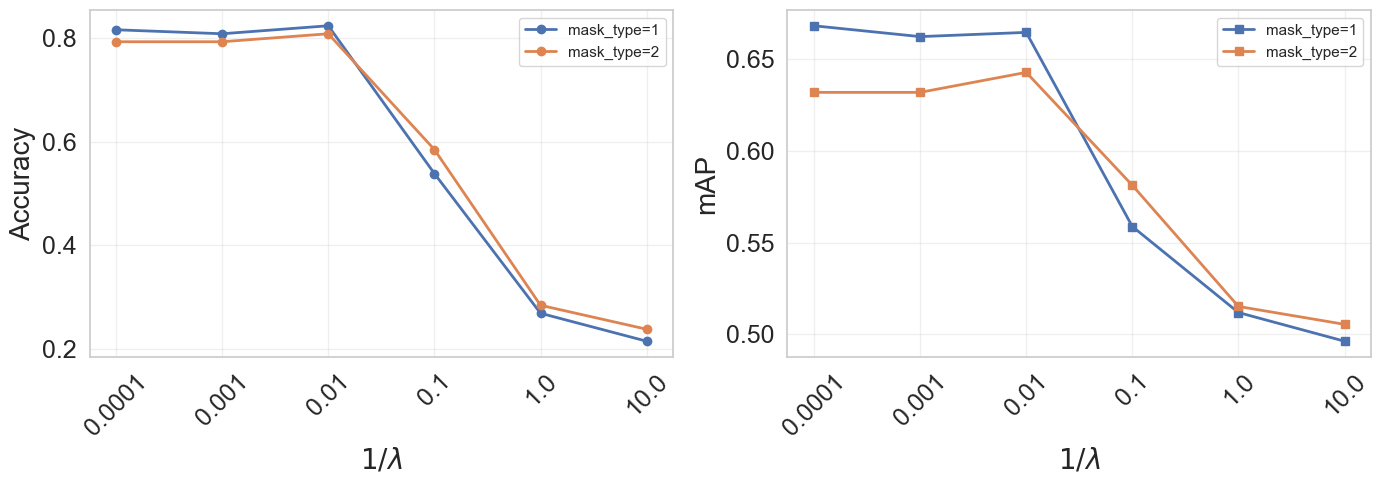

Figure saved to ablation_results\ablation_reg_mask12_ToeSegmentation2_k1.png


In [11]:
# ============================================================================
# DISPLAY + VISUALIZE REGULARIZATION ABLATION RESULTS
# ============================================================================

import matplotlib.pyplot as plt


def display_regularization_results():
    """Display accuracy/mAP summaries for regularization ablation."""
    if not os.path.exists(REG_RESULTS_FILE):
        print("No regularization results file found.")
        return None

    df = pd.read_csv(REG_RESULTS_FILE)
    if len(df) == 0:
        print("Regularization results file is empty.")
        return None

    print("\n" + "=" * 80)
    print(f"REGULARIZATION ABLATION RESULTS — fixed eps_threshold={EPS_THRESHOLD_DEFAULT}")
    print("=" * 80)

    print("\n--- Best accuracy rows (per mask_type, reg) ---")
    idx_best = df.groupby(['mask_type', 'reg'])['accuracy'].idxmax()
    best_df = df.loc[idx_best, ['mask_type', 'reg', 'k', 'accuracy', 'mAP', 'dist_time_sec', 'knn_time_sec']]
    print(best_df.sort_values(['mask_type', 'reg']).to_string(index=False))

    print("\n--- Runtime summary by mask_type and reg ---")
    runtime_df = (
        df.groupby(['mask_type', 'reg'])[['dist_time_sec', 'knn_time_sec', 'time_sec_per_k']]
        .mean()
        .reset_index()
        .sort_values(['mask_type', 'reg'])
    )
    print(runtime_df.to_string(index=False))

    overall_best = df.loc[df['accuracy'].idxmax()]
    print(
        f"\n*** Overall Best: mask_type={int(overall_best['mask_type'])}, reg={overall_best['reg']}, "
        f"k={int(overall_best['k'])}, accuracy={overall_best['accuracy']:.4f}, "
        f"mAP={overall_best['mAP']:.4f} ***"
    )

    return df


def visualize_regularization_ablation():
    """Plot accuracy and mAP curves vs reg for each mask type using k=1 only."""
    if not os.path.exists(REG_RESULTS_FILE):
        print("No regularization results file found.")
        return

    df = pd.read_csv(REG_RESULTS_FILE)
    if len(df) == 0:
        print("No regularization results to visualize.")
        return

    # Filter visualization to k=1 only
    df_k1 = df[df['k'] == 1].copy()
    if len(df_k1) == 0:
        print("No regularization results found for k=1.")
        return

    # Use discrete categorical x-axis for regularization values
    reg_levels = sorted(df_k1['reg'].unique())
    reg_levels_str = [str(v) for v in reg_levels]
    label_fontsize = 20
    tick_labelsize = 18
    x_label = r"$1/\lambda$"

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax1 = axes[0]
    for mask_type in sorted(df_k1['mask_type'].unique()):
        subset = df_k1[df_k1['mask_type'] == mask_type].sort_values('reg')
        x_cat = subset['reg'].astype(str)
        ax1.plot(x_cat, subset['accuracy'], marker='o', linewidth=2, label=f'mask_type={int(mask_type)}')
    ax1.set_xlabel(x_label, fontsize=label_fontsize)
    ax1.set_ylabel('Accuracy', fontsize=label_fontsize)
    # ax1.set_title(f'Accuracy vs reg (fixed eps={EPS_THRESHOLD_DEFAULT}, k=1)')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    ax1.set_xticks(reg_levels_str)
    ax1.tick_params(axis='x', rotation=45, labelsize=tick_labelsize)
    ax1.tick_params(axis='y', labelsize=tick_labelsize)

    ax2 = axes[1]
    for mask_type in sorted(df_k1['mask_type'].unique()):
        subset = df_k1[df_k1['mask_type'] == mask_type].sort_values('reg')
        x_cat = subset['reg'].astype(str)
        ax2.plot(x_cat, subset['mAP'], marker='s', linewidth=2, label=f'mask_type={int(mask_type)}')
    ax2.set_xlabel(x_label, fontsize=label_fontsize)
    ax2.set_ylabel('mAP', fontsize=label_fontsize)
    # ax2.set_title(f'mAP vs reg (fixed eps={EPS_THRESHOLD_DEFAULT}, k=1)')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    ax2.set_xticks(reg_levels_str)
    ax2.tick_params(axis='x', rotation=45, labelsize=tick_labelsize)
    ax2.tick_params(axis='y', labelsize=tick_labelsize)

    plt.tight_layout()
    fig_path = os.path.join(RESULTS_DIR, f"ablation_reg_mask12_{DATASET_NAME}_k1.png")
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Figure saved to {fig_path}")


reg_results_df = display_regularization_results()
visualize_regularization_ablation()
